# Retrieval

In [1]:
from pathlib import Path # For Loading the directory or PDF path .
from typing import Any, Dict, List, Optional, Tuple
from dataclasses import dataclass, field
from config import Config, cfg
from dotenv import load_dotenv # Used for loading Huggingface api .



In [2]:
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

In [3]:
import sys

NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" if (PROJECT_ROOT / "notebooks").exists() else PROJECT_ROOT
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT))

In [4]:
# Removing unwanted warnings from sentence transformers library .(Optional)
import warnings
from transformers import logging

logging.set_verbosity_error()
warnings.filterwarnings("ignore", message=".*position_ids.*UNEXPECTED.*")

In [5]:
load_dotenv() # For loading Huggingface api .

True

In [6]:
import statistics
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from rank_bm25 import BM25Okapi
import re
import nltk

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    pass
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    pass

FALLBACK_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "has",
    "he", "in", "is", "it", "its", "of", "on", "that", "the", "to", "was",
    "were", "will", "with"
}

In [7]:
def safe_word_tokenize(text: str) -> List[str]:
    try:
        return word_tokenize(text)
    except LookupError:
        return re.findall(r"[A-Za-z0-9]+", text)

In [8]:
def get_stopword_set() -> set:
    try:
        return set(stopwords.words("english"))
    except LookupError:
        return set(FALLBACK_STOPWORDS)

In [9]:
import numpy as np # Used for storing embeddings .
import torch # For device selection , model execution and tensor operation .
import open_clip # Image embedding model .
from typing import List, Dict,Tuple # Used for type return .

In [10]:
# Used for loading embedding model and embedding images with their caption .
class ImageEmbeddingModel:
    """
    Embed document images with OpenCLIP.

    Each image can optionally be fused with its nearby caption so the final
    vector carries both visual and textual cues. Batching is used to take
    advantage of the GPU instead of processing one image at a time.
    """

    def __init__(
        self,
        model_name: str = cfg.image_embed_model,
        pretrained: str = cfg.image_embed_pretrained,
        caption_image_weight: float = cfg.image_caption_image_weight,
        batch_size: int = cfg.image_embed_batch_size
    ):
        self.model_name = model_name
        self.pretrained = pretrained
        self.caption_image_weight = caption_image_weight
        self.batch_size = batch_size
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        try:
            self.model, self.preprocess, _ = open_clip.create_model_and_transforms(
                model_name=model_name,
                pretrained=pretrained
            )
            self.tokenizer = open_clip.get_tokenizer(model_name)
        except Exception as e:
            raise RuntimeError(f"Failed to load OpenCLIP model '{model_name}': {e}") from e

        self.model = self.model.to(self.device)
        self.model.eval()

        if self.device == "cuda":
            print(f"OpenCLIP running on {torch.cuda.get_device_name(0)}.")
        else:
            print("OpenCLIP running on CPU.")

        model_config = open_clip.get_model_config(self.model_name)
        self.embed_dim = model_config["embed_dim"]
        print(f"Embedding dimension of {self.model_name} is {self.embed_dim}")

    @torch.no_grad()
    def embed_image(self, image_objects: List[Dict]) -> Tuple[np.ndarray, float, Dict]:
        if not image_objects:
            raise ValueError("No images in the image objects.")

        start_time = perf_counter()
        valid_objects: List[Dict] = []
        captions: List[str] = []
        image_tensors: List[torch.Tensor] = []

        for image_object in image_objects:
            image_path = image_object.get("path")
            try:
                pil_image = Image.open(image_path).convert("RGB")
            except Exception as e:
                print(f"Failed to load {image_path}: {e}")
                continue

            image_tensors.append(self.preprocess(pil_image))
            raw_caption = image_object.get("caption_text") or ""
            captions.append(raw_caption.strip() if isinstance(raw_caption, str) else "")
            valid_objects.append(image_object)

        if not image_tensors:
            raise ValueError("No valid images were processed. All images failed to load.")

        image_embeddings: List[np.ndarray] = []
        for batch_start in range(0, len(image_tensors), self.batch_size):
            batch_tensor = torch.stack(
                image_tensors[batch_start: batch_start + self.batch_size]
            ).to(self.device)
            batch_embeddings = self.model.encode_image(batch_tensor)
            batch_embeddings = batch_embeddings / batch_embeddings.norm(dim=-1, keepdim=True)
            image_embeddings.extend(batch_embeddings.cpu().numpy())

        caption_weight = 1.0 - self.caption_image_weight
        final_embeddings: List[np.ndarray] = []

        for image_embedding, caption in zip(image_embeddings, captions):
            if caption:
                tokens = self.tokenizer([caption]).to(self.device)
                caption_embedding = self.model.encode_text(tokens)
                caption_embedding = caption_embedding / caption_embedding.norm(dim=-1, keepdim=True)
                caption_embedding = caption_embedding.cpu().numpy()[0]
                fused_embedding = (
                    self.caption_image_weight * image_embedding +
                    caption_weight * caption_embedding
                )
                norm = np.linalg.norm(fused_embedding)
                if norm > 1e-8:
                    fused_embedding = fused_embedding / norm
                final_embeddings.append(fused_embedding)
            else:
                final_embeddings.append(image_embedding)

        total_time = perf_counter() - start_time
        avg_time = total_time / len(final_embeddings) if final_embeddings else 0.0

        stats = {
            "count": len(image_objects),
            "embeddings_created": len(final_embeddings),
            "failed_loads": len(image_objects) - len(valid_objects),
            "total_time": total_time,
            "avg_time": avg_time,
            "dimension": self.embed_dim,
            "caption_image_weight": self.caption_image_weight
        }

        return np.vstack(final_embeddings), total_time, stats

    @torch.no_grad()
    def embed_query(self, query: str) -> np.ndarray:
        if not isinstance(query, str):  # Checking if query is valid.
            raise TypeError("Query must be a string.")
        if not query.strip():
            raise ValueError("Please give a valid prompt.")
        tokens = self.tokenizer([query]).to(self.device)  # Convert to tensor.
        query_embedding = self.model.encode_text(tokens)  # Embedding text or tensor value.
        query_embedding = query_embedding / query_embedding.norm(dim=-1, keepdim=True)  # Normalizing values
        query_embedding = query_embedding.cpu().numpy()[0]  # Converting tensor to numpy array.
        return query_embedding  # Returning the embedding.

In [11]:
from sentence_transformers import SentenceTransformer # Used for loading model .
import numpy as np # Used to store embedding .
import torch # Used for device selection and model execution .
from typing import List # Used for return type .
from langchain_core.documents import Document # Used for storing documents .
from time import perf_counter

In [12]:
# Used for loading model and embedding text .
class TextEmbeddingModel:
    def __init__(self, model_name: str = cfg.text_embed_model, batch_size: int = cfg.text_embed_batch_size):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"  # Device check.
        self.batch_size = batch_size

        try:
            self.model = SentenceTransformer(model_name_or_path=model_name, device=self.device)  # Loading model.
        except Exception as e:
            raise RuntimeError(f"Failed to load SentenceTransformer model: {e}")

        self.query_prefix = "Represent this sentence for searching relevant passages: "

        if self.device == "cuda":
            print(f"BGE running on {torch.cuda.get_device_name(0)}.")
        else:
            print("BGE running on CPU.")
        print(f"Embedding dimension of {model_name} is {self.model.get_sentence_embedding_dimension()}")

    @torch.no_grad()
    def embed_documents(self, documents: List[Document]) -> Tuple:
        if not documents:
            raise ValueError("No documents to embed.")

        texts = []
        for doc in documents:  # Checking if data is available in documents.
            if hasattr(doc, "page_content") and doc.page_content:
                content = doc.page_content.strip()
                if content:
                    texts.append(content)

        if not texts:
            raise ValueError("No valid document content to embed. All documents are empty.")

        # Embedding texts.
        # sentences -> input/texts
        # batch_size -> Number of inputs embedding at a single time.
        # convert_to_numpy -> Convert output to numpy array.
        # normalize_embeddings -> Normalizing all the output vectors.

        start_time = perf_counter()  # Start the timer before text embedding starts . # M1 (Embedding time )

        text_embeddings = self.model.encode(
            sentences=texts,
            batch_size=self.batch_size,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False
        )
        total_time = perf_counter() - start_time  # Calculate total time took to embedd .
        avg_time = total_time / len(texts)  # Calculate average time .

        # Store stats in dict instead of printing
        stats = {
            "count": len(texts),
            "embeddings_created": len(text_embeddings),
            "total_time": total_time,
            "avg_time": avg_time,
            "dimension": self.model.get_sentence_embedding_dimension()
        }

        return text_embeddings, total_time, stats  # Return embeddings, time, and stats.

    # The following function is used to create embedding for user input prompt.
    @torch.no_grad()
    def embed_query(self, query: str) -> np.ndarray:
        if not isinstance(query, str):  # Checking if query is valid.
            raise TypeError("Query must be a string.")

        if not query.strip():  # Checking if the prompt is not empty.
            raise ValueError("Given prompt is not valid.")

        query = self.query_prefix + query  # Adding a prefix to prompt since BGE is instruction-based (only for query, not documents).

        query_embedding = self.model.encode(  # Embedding query.
            sentences=query,
            normalize_embeddings=True,
            convert_to_numpy=True,
            show_progress_bar=False
        )

        return query_embedding  # Returning embedded values.

In [13]:
text_model=TextEmbeddingModel()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BGE running on NVIDIA GeForce RTX 3050 6GB Laptop GPU.
Embedding dimension of BAAI/bge-large-en-v1.5 is 1024


In [14]:
from typing import Tuple, Dict, List, Optional

In [15]:
import json # Used for receiving image object or document while creating a hash id .
from typing import List,Dict,Union,Optional # For datatype of a variable .
import chromadb # Used for creating a vectorDB .
import os # For getting directory path for storing vector database .
import hashlib # Used for creating hashid for documents
import numpy as np
from langchain_core.documents import Document
# The following function is used to create hashid using content of a document or image object

In [16]:
def stable_hash(obj:dict|str)->str:
    if isinstance(obj,dict):
        obj=json.dumps(obj,sort_keys=True,ensure_ascii=False)
    elif not isinstance(obj,str):
        raise TypeError(f"stable_hash expects dict or str, got {type(obj)}")

    return hashlib.sha256(obj.encode("utf-8")).hexdigest()

In [17]:
# The following function is used to remove None type and replace it with empty string since chromadb cannot store type None .
def sanitize_metadata(metadata: dict) -> dict:
    if not isinstance(metadata,dict): # Type validation .
        raise TypeError(f"sanitize_metadata expects dict , got {type(metadata)}")

    clean = {}
    for k, v in metadata.items():
        if v is None:
            clean[k] = "" # None -> Empty string
        elif isinstance(v, (str, int, float, bool)):
            clean[k] = v # Keep it as it is .
        elif isinstance(v, (list, tuple, dict)):
            clean[k] = json.dumps(v, ensure_ascii=False)
        else:
            clean[k] = str(v) # Convert unknown type to string .

    return clean # Return sanitized metadata .

In [18]:
def deserialize_metadata(metadata: dict) -> dict:
    if not isinstance(metadata, dict):
        return {}

    parsed = dict(metadata)
    for key in ["related_image_ids", "bbox"]:
        value = parsed.get(key)
        if isinstance(value, str) and value.strip():
            try:
                parsed[key] = json.loads(value)
            except json.JSONDecodeError:
                parsed[key] = value
    return parsed

In [19]:
# Used for initializing vectorDB and also store data in collection .
class VectorStore:
    def __init__(self, collection_name: str, directory: str = cfg.database_dir, silent: bool = False):
        if not collection_name or not isinstance(collection_name, str):
            raise ValueError("Collection name must be a non-empty string.")
        self.collection_name = collection_name  # Collection name.
        self.persistent_directory = directory  # Directory to store database.
        self.collection = None  # Collection, used to store data.
        self.client = None  # Used to connect database.
        self.silent = silent  # Flag to suppress printing
        self._existing_ids = set()
        self.initialize_store()  # Initializing vectorDB.

    def initialize_store(self):
        try:
            os.makedirs(name=self.persistent_directory, exist_ok=True)  # Checking if directory exists; if not, creating one.
            self.client = chromadb.PersistentClient(path=self.persistent_directory)
            if self.collection_exists(self.collection_name):  # Checking if the collection exists; if so, load it.
                if not self.silent:
                    print(f"Loading collection {self.collection_name} from database.")
                self.collection = self.client.get_collection(self.collection_name)
            else:  # If collection does not exist, create it.
                if not self.silent:
                    print(f"New collection {self.collection_name} created in database.")
                self.collection = self.client.create_collection(name=self.collection_name, metadata={"hnsw:space": "cosine"})
            self._existing_ids = set(self.collection.get(include=[])["ids"])
            if not self.silent:
                print(f"Vector store initialized.")  # Success message.
                print(f"Existing documents in collection: {len(self._existing_ids)}")
        except Exception as e:  # Exception handling.
            raise RuntimeError(f"Could not initialize vector store: {e}") from e

    # The following function is used to add data and its embeddings to a collection.
    def add_documents(self, documents: List[Union[Dict, Document]], embeddings: np.ndarray):
        if not self.collection:  # Checking if collection is initialized.
            raise RuntimeError("Collection is not initialized.")
        if not documents:
            raise ValueError("Documents list is empty.")
        if len(documents) != len(embeddings):  # Checking if number of documents and embeddings are the same.
            raise ValueError(f"Number of documents ({len(documents)}) does not match embeddings ({len(embeddings)}).")

        ids, metadatas, texts = [], [], []  # Used to store main content and metadata.
        for doc in documents:
            if isinstance(doc, Document):  # For text embeddings. Document type.
                content = doc.page_content.strip()
                if not content:
                    continue
                metadata = doc.metadata or {}
                metadata = sanitize_metadata(metadata)
                hash_input = {  # Data used for creating hashid.
                    "content": content,
                    "source": metadata.get("source"),
                    "page": metadata.get("page_num", "")
                }
                doc_id = stable_hash(hash_input)
                texts.append(content)  # Appending data to store in vectorDB
                metadatas.append(metadata)
                ids.append(doc_id)
            elif isinstance(doc, dict):  # For image embeddings. Dict type.
                bbox = doc.get("bbox")
                image_metadata = {
                    "image_path": doc.get("path", ""),
                    "caption_text": doc.get("caption_text", ""),
                    "bbox": json.dumps(bbox) if bbox is not None else "",
                }
                image_metadata = sanitize_metadata(image_metadata)  # Removing None or unknown datatype.
                hash_input = {  # Used for hashid.
                    "image_path": image_metadata["image_path"],
                    "bbox": image_metadata["bbox"],
                    "caption": image_metadata["caption_text"],
                }
                doc_id = stable_hash(hash_input)
                texts.append(doc.get("caption_text", ""))  # Appending data to store in vectorDB
                metadatas.append(image_metadata)
                ids.append(doc_id)
            else:
                raise TypeError(f"Unsupported document type: {type(doc)}")  # If input is neither Document nor Dict.

        if not ids:
            if not self.silent:
                print("No valid documents to process.")
            return

        seen = set()
        new_indices = []
        for i, doc_id in enumerate(ids):  # Check for redundant documents.
            if doc_id in self._existing_ids or doc_id in seen:
                continue
            seen.add(doc_id)
            new_indices.append(i)

        if not new_indices:  # Checking if there are new documents to add to collection.
            if not self.silent:
                print("No new documents to add")
            return

        self.collection.add(  # Adding new documents to collection
            ids=[ids[i] for i in new_indices],
            documents=[texts[i] for i in new_indices],
            metadatas=[metadatas[i] for i in new_indices],
            embeddings=[embeddings[i].tolist() for i in new_indices]
        )
        self._existing_ids.update(ids[i] for i in new_indices)
        if not self.silent:
            print(f"Added {len(new_indices)} new documents to collection.")

    # The following function is used to check if the collection exists.
    def collection_exists(self, collection_name: str) -> bool:
        collections_in_db = self.client.list_collections()
        return any(col.name == collection_name for col in collections_in_db)

    # The following function is used to query and get relevant documents.
    def query(self, query_embedding: np.ndarray, k: int = 5, where: Optional[Dict] = None):
        if not self.collection:  # Checking if collection is initialized.
            raise RuntimeError("Collection is not initialized.")
        if query_embedding.ndim != 1:  # Checking if query is 1-dimensional.
            raise ValueError("Query embedding must be a 1D vector.")
        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        results = self.collection.query(  # Storing results.
            query_embeddings=[query_embedding.tolist()],
            n_results=k,  # Getting top results.
            where=where,  # Acts as a filter.
            include=["documents", "metadatas", "distances"]  # Including the following data.
        )
        return results

    # The following function is used to get stats about the collection.
    def get_collection_stats(self) -> Dict:
        if not self.collection:
            raise RuntimeError("Collection is not initialized.")
        # Stats about collection . M2 (Collection count)
        return {
            "name": self.collection_name,
            "count": self.collection.count(),
            "directory": self.persistent_directory
        }

    # The following function is used to delete current collection.
    def delete_collection(self) -> None:
        if not self.collection:
            raise RuntimeError("Collection is not initialized.")
        self.client.delete_collection(name=self.collection_name)
        self.collection = None
        self._existing_ids.clear()
        print(f"Collection {self.collection_name} deleted.")

In [20]:
from PIL import Image
import os
from typing import List,Dict,Optional
from sentence_transformers import CrossEncoder

In [21]:
# Used to rerank the chunks with relevance .
class Reranker:
    def __init__(self, model_name: str = cfg.reranker_model):
        self.model = CrossEncoder(model_name)
        print(f"Reranker initialized: {model_name}")

    def rerank(self, query: str, items: List[Dict], top_k: int = cfg.rerank_k) -> List[Dict]:
        if not items:  # Checking if chunks are empty.
            return []

        pairs = [[query, item["text"]] for item in items]
        scores = self.model.predict(pairs)  # Reranking distances.

        ranked = sorted(  # Ranking based on score.
            zip(items, scores),
            key=lambda x: x[1],
            reverse=True  # Higher score is better.
        )

        return [item for item, _ in ranked[:top_k]]  # Returning top k chunks.

In [22]:
@dataclass
class RetrievalItem:
    """
    One ranked retrieval result from either the text collection or image collection.
    """
    doc_id: str
    text: str
    metadata: Dict[str, Any]
    distance: float
    similarity: float
    fused_score: Optional[float]
    rank: int
    modality: str
    retrieval_latency_sec: float

In [23]:
@dataclass
class RetrievalOutput:
    """
    Structured retrieval response used by the main pipeline and evaluation code.

    The properties below rebuild the older nested-dictionary format so existing
    formatting and metric utilities can keep working while the pipeline gains a
    more explicit internal structure.
    """
    query: str
    text_items: List[RetrievalItem]
    image_items: List[RetrievalItem]
    text_latency_sec: float
    image_latency_sec: float
    total_latency_sec: float
    cosine_sim_text: float
    cosine_sim_image: float
    search_mode: str
    hybrid_stats: Dict[str, Any] = field(default_factory=dict)

    @property
    def text_results(self) -> Dict:
        return {
            "documents": [[item.text for item in self.text_items]],
            "metadatas": [[item.metadata for item in self.text_items]],
            "distances": [[item.distance for item in self.text_items]],
            "ids": [[item.doc_id for item in self.text_items]],
            "fused_scores": [[item.fused_score for item in self.text_items]],
            "retrieval_metrics": {
                "text_search_time": round(self.text_latency_sec, 4),
                "search_mode": self.search_mode,
                "hybrid_stats": self.hybrid_stats
            }
        }

    @property
    def image_results(self) -> Dict:
        return {
            "documents": [[item.text for item in self.image_items]],
            "metadatas": [[item.metadata for item in self.image_items]],
            "distances": [[item.distance for item in self.image_items]],
            "ids": [[item.doc_id for item in self.image_items]],
            "retrieval_metrics": {
                "image_search_time": round(self.image_latency_sec, 4),
                "image_total_retrieval_time": round(self.image_latency_sec, 4)
            }
        }

    @property
    def retrieval_metrics(self) -> Dict:
        blended_similarity = 0.0
        if self.text_items and self.image_items:
            blended_similarity = (self.cosine_sim_text + self.cosine_sim_image) / 2.0
        elif self.text_items:
            blended_similarity = self.cosine_sim_text
        elif self.image_items:
            blended_similarity = self.cosine_sim_image

        return {
            "overall_retrieval_time": self.total_latency_sec,
            "cosine_similarity": blended_similarity,
            "cosine_similarity_text": self.cosine_sim_text,
            "cosine_similarity_image": self.cosine_sim_image,
            "text_metrics": {
                "text_search_time": round(self.text_latency_sec, 4),
                "text_total_retrieval_time": round(self.text_latency_sec, 4)
            },
            "image_metrics": {
                "image_search_time": round(self.image_latency_sec, 4),
                "image_total_retrieval_time": round(self.image_latency_sec, 4)
            },
            "search_mode": self.search_mode,
            "hybrid_stats": self.hybrid_stats
        }

    def to_legacy_dict(self) -> Dict:
        return {
            "query": self.query,
            "text_results": self.text_results,
            "image_results": self.image_results,
            "retrieval_metrics": self.retrieval_metrics
        }

    def get(self, key: str, default=None):
        return self.to_legacy_dict().get(key, default)

    def keys(self):
        return self.to_legacy_dict().keys()

    def items(self):
        return self.to_legacy_dict().items()

    def values(self):
        return self.to_legacy_dict().values()

    def __getitem__(self, key: str):
        return self.to_legacy_dict()[key]

    def __contains__(self, key: str) -> bool:
        return key in self.to_legacy_dict()

    def __iter__(self):
        return iter(self.to_legacy_dict())

In [24]:
class ContextFormatter:
    def __init__(self, max_text_chunks: int = cfg.max_text_chunks, max_images: int = cfg.max_images,
                 text_distance_threshold: float = cfg.text_distance_threshold,
                 image_distance_threshold: float = cfg.image_distance_threshold,
                 use_percentile_filtering: bool = True,
                 percentile_cutoff: int = cfg.percentile_cutoff):

        self.max_text_chunks = max_text_chunks
        self.max_images = max_images
        self.text_distance_threshold = text_distance_threshold
        self.image_distance_threshold = image_distance_threshold
        self.use_percentile_filtering = use_percentile_filtering
        self.percentile_cutoff = percentile_cutoff

    def _flatten_results(self, results: Dict) -> List[Dict]:
        if not results or not isinstance(results, dict):
            return []
        documents = results.get("documents", [[]])[0]
        metadatas = results.get("metadatas", [[]])[0]
        distances = results.get("distances", [[]])[0]
        ids = results.get("ids", [[]])[0]

        # Handle fused scores if present
        fused_scores = results.get("fused_scores", [[]])[0]
        bm25_scores = results.get("bm25_scores", [[]])[0]

        min_length = min(len(documents), len(metadatas), len(distances), len(ids) if ids else len(documents))
        if min_length == 0:
            return []

        flattened = []
        for i in range(min_length):
            item = {
                "doc_id": ids[i] if ids else "",
                "text": documents[i],
                "metadata": deserialize_metadata(metadatas[i]),
                "distance": float(distances[i]),
                "rank": i + 1
            }
            if fused_scores and i < len(fused_scores):
                item["fused_score"] = fused_scores[i]
            if bm25_scores and i < len(bm25_scores):
                item["bm25_raw_score"] = bm25_scores[i]
            flattened.append(item)
        return flattened

    def _select_text_chunks(self, text_results: Dict) -> List[Dict]:
        items = self._flatten_results(text_results)
        if not items:
            return []
        distances = [i["distance"] for i in items]
        if self.use_percentile_filtering and len(distances) > 2:
            threshold = np.percentile(distances, self.percentile_cutoff)
            filtered = [i for i in items if i["distance"] <= threshold]
        else:
            filtered = [i for i in items if i["distance"] <= self.text_distance_threshold]

        # Strict deduplication
        seen = set()
        unique = []
        for item in filtered:
            text_hash = hashlib.md5(item["text"].encode()).hexdigest()[:16]
            if text_hash not in seen:
                seen.add(text_hash)
                unique.append(item)
        filtered = unique

        # When hybrid fusion is active, some items may still have no fused score.
        # In that case we fall back to 0.0 so sorting stays stable.
        has_real_fused_scores = any(item.get("fused_score") is not None for item in filtered)
        if has_real_fused_scores:
            filtered.sort(
                key=lambda x: x.get("fused_score") if x.get("fused_score") is not None else 0.0,
                reverse=True
            )
        else:
            filtered.sort(key=lambda x: x["distance"])

        return filtered[:self.max_text_chunks]

    def _load_image(self, image_path: str) -> Optional[Image.Image]:
        if not image_path or not isinstance(image_path, str):
            return None
        if not os.path.exists(image_path):
            print(f"Warning: Image path does not exist: {image_path}")
            return None
        try:
            return Image.open(image_path).convert("RGB")
        except Exception as e:
            print(f"Failed to load image {image_path}: {e}")
            return None

    def _format_text_context(self, text_items: List[Dict]) -> str:
        if not text_items or not isinstance(text_items, list):
            return ""
        lines = []
        for idx, item in enumerate(text_items, start=1):
            if not isinstance(item, dict):
                continue
            meta = item["metadata"] or {}
            source = meta.get("source", "unknown")
            page = meta.get("page_num", "N/A")
            text = item["text"].strip()
            if not text:
                continue
            lines.append(
                f"[{idx}] {text}\n"
                f"(Source: {source}, page {page})"
            )
        return "\n\n".join(lines)

    def _select_images(self, image_results: Dict) -> List[Dict]:
        items = self._flatten_results(image_results)
        if not items:
            return []
        items = [
            i for i in items if i["distance"] <= self.image_distance_threshold
        ]
        items.sort(key=lambda x: x["distance"])
        return items[:self.max_images]

    def _format_image_context(self, image_items: List[Dict]) -> List[Dict]:
        if not image_items or not isinstance(image_items, list):
            return []
        formatted_images = []
        for item in image_items:
            if not isinstance(item, dict):
                continue
            meta = item.get("metadata") or {}
            image_path = meta.get("image_path")
            caption = meta.get("caption_text", "").strip()
            image = self._load_image(image_path)
            if image is None:
                continue
            formatted_images.append({
                "image": image,
                "caption": caption
            })
        return formatted_images

    def format(self, retrieval_output: Dict) -> Dict:
        if hasattr(retrieval_output, "to_legacy_dict"):
            retrieval_output = retrieval_output.to_legacy_dict()
        if not retrieval_output or not isinstance(retrieval_output, dict):
            raise ValueError("retrieval_output must be a non-empty dictionary.")
        query = retrieval_output.get("query", "")
        text_items = self._select_text_chunks(
            retrieval_output.get("text_results", {})
        )
        image_items = self._select_images(
            retrieval_output.get("image_results", {})
        )
        return {
            "query": query,
            "text_context": self._format_text_context(text_items),
            "images": self._format_image_context(image_items)
        }

In [25]:
class BM25Index:
    def __init__(self, documents: List[str], doc_ids: List[str], metadatas: List[Dict],
                 enable_preprocessing: bool = True):
        self.doc_ids = doc_ids
        self.documents = documents
        self.metadatas = metadatas
        self.stemmer = PorterStemmer()
        self.stop_words = get_stopword_set()

        self.domain_stopwords = {
            'et', 'al', 'using', 'used', 'shown', 'show',
            'via', 'thus', 'therefore', 'hence'
        }
        self.stop_words.update(self.domain_stopwords)

        if enable_preprocessing:
            self.processed_docs = [self._preprocess(doc) for doc in documents]
        else:
            self.processed_docs = [safe_word_tokenize(doc.lower()) for doc in documents]

        self.bm25 = BM25Okapi(self.processed_docs)
        self.enable_preprocessing = enable_preprocessing

        # Store corpus statistics
        self.corpus_tokens = set()
        for doc in self.processed_docs:
            self.corpus_tokens.update(doc)

        # Track query statistics
        self.query_stats_history = []

        print(f"BM25 index built over {len(documents)} documents with preprocessing={enable_preprocessing}")

    def _preprocess(self, text: str) -> List[str]:
        if not text:
            return []

        text = text.lower()
        text = re.sub(r'([a-z])(\d)', r'\1 \2', text)
        text = re.sub(r'(\d)([a-z])', r'\1 \2', text)

        tokens = safe_word_tokenize(text)
        processed = []

        for token in tokens:
            if token.isdigit() or (any(c.isdigit() for c in token) and any(c.isalpha() for c in token)):
                processed.append(token)
                continue

            if token in self.stop_words or len(token) < 3:
                continue

            stemmed = self.stemmer.stem(token)
            processed.append(stemmed)

        return processed

    def _expand_query(self, tokens: List[str]) -> List[str]:
        expanded = set(tokens)

        for token in tokens:
            variants = [
                token + 's', token + 'es', token + 'ed', token + 'ing',
                token[:-1] if token.endswith('s') else None,
                token[:-2] if token.endswith('es') else None
            ]
            for var in variants:
                if var and var in self.corpus_tokens:
                    expanded.add(var)

        return list(expanded)

    def query(self, query: str, k: int = 10, expand_query: bool = True) -> Dict:
        if not query or not query.strip():
            raise ValueError("Query must be a non-empty string.")

        tokenized_query = self._preprocess(query)

        if not tokenized_query:
            tokenized_query = safe_word_tokenize(query.lower())
            tokenized_query = [t for t in tokenized_query if t not in self.stop_words and len(t) > 2]

        if expand_query:
            tokenized_query = self._expand_query(tokenized_query)

        scores = self.bm25.get_scores(tokenized_query)
        top_indices = np.argsort(scores)[::-1][:k]

        # Calculate statistics for this query
        top_scores = [float(scores[i]) for i in top_indices if scores[i] > 0]
        stats = {
            "query_length_tokens": len(tokenized_query),
            "expanded_tokens": len(tokenized_query) if expand_query else 0,
            "max_score": max(top_scores) if top_scores else 0.0,
            "mean_score": statistics.mean(top_scores) if top_scores else 0.0,
            "min_score": min(top_scores) if top_scores else 0.0,
            "std_score": statistics.stdev(top_scores) if len(top_scores) > 1 else 0.0,
            "non_zero_docs": len([s for s in scores if s > 0]),
            "corpus_coverage": len([s for s in scores if s > 0]) / len(scores) if len(scores) > 0 else 0.0
        }
        self.query_stats_history.append(stats)

        results = {
            "documents": [[self.documents[i] for i in top_indices]],
            "metadatas": [[self.metadatas[i] for i in top_indices]],
            "ids": [[self.doc_ids[i] for i in top_indices]],
            "scores": [float(scores[i]) for i in top_indices],
            "query_tokens": tokenized_query,
            "bm25_stats": stats  # Include stats in result
        }
        return results

In [26]:
class BM25IndexBuilder:
    @staticmethod
    def from_vectorstore(vectorstore: 'VectorStore', enable_preprocessing: bool = True) -> 'BM25Index':
        if not vectorstore.collection:
            raise RuntimeError("VectorStore collection is not initialized.")

        all_data = vectorstore.collection.get(include=["documents", "metadatas"])
        documents = all_data.get("documents", [])
        metadatas = all_data.get("metadatas", [])
        doc_ids = all_data.get("ids", [])

        if not documents:
            raise RuntimeError("No documents found in VectorStore to build BM25 index.")

        print(f"Building BM25 index from {len(documents)} documents.")
        return BM25Index(
            documents=documents,
            doc_ids=doc_ids,
            metadatas=metadatas,
            enable_preprocessing=enable_preprocessing)

In [27]:
# Used to retrieve documents from database using input query from user .
class RetrievalRag:
    def __init__(self, image_embedder: 'ImageEmbeddingModel', text_embedder: 'TextEmbeddingModel',
                 image_vectordb: 'VectorStore', text_vectordb: 'VectorStore',
                 use_reranker: bool = cfg.use_reranker, use_hybrid: bool = cfg.use_hybrid,
                 bm25_weight: float = cfg.bm25_weight, semantic_weight: float = cfg.semantic_weight,
                 formatter: Optional['ContextFormatter'] = None,
                 adaptive_weighting: bool = cfg.adaptive_weighting,
                 score_fusion: bool = cfg.score_fusion):

        self.image_embedder = image_embedder
        self.text_embedder = text_embedder
        self.image_vectordb = image_vectordb
        self.text_vectordb = text_vectordb
        self.reranker = Reranker() if use_reranker else None
        self.formatter = formatter or ContextFormatter()
        self.use_hybrid = use_hybrid
        self.adaptive_weighting = adaptive_weighting
        self.score_fusion = score_fusion

        if not (0.0 <= bm25_weight <= 1.0) or not (0.0 <= semantic_weight <= 1.0):
            raise ValueError("BM25 and semantic weights must be between 0.0 and 1.0.")
        if abs((bm25_weight + semantic_weight) - 1.0) > 1e-6:
            raise ValueError("BM25 weight and semantic weight must sum to 1.0.")

        self.bm25_weight = bm25_weight
        self.semantic_weight = semantic_weight

        # Performance tracking
        self.hybrid_metrics_history = []

        if self.use_hybrid:
            self.bm25_index = BM25IndexBuilder.from_vectorstore(text_vectordb, enable_preprocessing=True)
            print(f"Hybrid search enabled: {'Score-based fusion' if score_fusion else 'RRF'} with adaptive={adaptive_weighting}")
        else:
            self.bm25_index = None
            print("Hybrid search disabled: using semantic search only.")

    def _classify_query_type(self, query: str) -> str:
        query_lower = query.lower().strip()
        words = query_lower.split()
        word_count = len(words)
        num_count = len(re.findall(r'\d+', query_lower))

        # Short or numeric-heavy queries → BM25 strong (keyword retrieval)
        if word_count <= 4 or (num_count > 0 and num_count / max(word_count, 1) > 0.25):
            return 'keyword'
        # Long or explanatory queries → embeddings strong (semantic retrieval)
        elif word_count >= 9 or any(w in query_lower for w in ['why', 'how', 'explain', 'describe', 'what', 'compare', 'analyze']):
            return 'semantic'
        else:
            return 'balanced'

    def _normalize_scores(self, scores: List[float], method: str = 'minmax') -> List[float]:
        if not scores:
            return []

        scores = np.array(scores)

        if method == 'minmax':
            min_score, max_score = np.min(scores), np.max(scores)
            if max_score - min_score < 1e-6:
                return [0.5] * len(scores)
            normalized = (scores - min_score) / (max_score - min_score)
        elif method == 'zscore':
            mean, std = np.mean(scores), np.std(scores)
            if std < 1e-6:
                return [0.5] * len(scores)
            normalized = (scores - mean) / std
            normalized = (normalized - np.min(normalized)) / (np.max(normalized) - np.min(normalized) + 1e-6)
        else:
            exp_scores = np.exp(scores - np.max(scores))
            normalized = exp_scores / np.sum(exp_scores)

        return normalized.tolist()

    def _calculate_overlap(self, list1: List[str], list2: List[str]) -> Dict:
        """Calculate overlap statistics between two result lists"""
        set1, set2 = set(list1), set(list2)
        intersection = set1 & set2
        union = set1 | set2

        return {
            "intersection_size": len(intersection),
            "union_size": len(union),
            "jaccard_similarity": len(intersection) / len(union) if union else 0.0,
            "overlap_percentage": (len(intersection) / len(set1) * 100) if set1 else 0.0,
            "intersection_ids": list(intersection)
        }

    def _fuse_scores(self, bm25_results: Dict, semantic_results: Dict) -> Tuple[Dict, Dict]:
        bm25_docs = bm25_results.get("documents", [[]])[0]
        bm25_ids = bm25_results.get("ids", [[]])[0]
        bm25_metas = bm25_results.get("metadatas", [[]])[0]
        bm25_scores = bm25_results.get("scores", [])

        sem_docs = semantic_results.get("documents", [[]])[0]
        sem_ids = semantic_results.get("ids", [[]])[0]
        sem_metas = semantic_results.get("metadatas", [[]])[0]
        sem_distances = semantic_results.get("distances", [[]])[0]

        sem_scores = [1.0 - float(d) for d in sem_distances]

        norm_bm25 = self._normalize_scores(bm25_scores, method='minmax')
        norm_semantic = self._normalize_scores(sem_scores, method='minmax')

        combined = {}

        for idx, doc_id in enumerate(bm25_ids):
            combined[doc_id] = {
                "text": bm25_docs[idx],
                "metadata": bm25_metas[idx],
                "bm25_norm": norm_bm25[idx],
                "semantic_norm": 0.0,
                "bm25_raw": bm25_scores[idx],
                "semantic_dist": 2.0,
                "semantic_sim": 0.0
            }

        for idx, doc_id in enumerate(sem_ids):
            sem_score = norm_semantic[idx]
            if doc_id in combined:
                combined[doc_id]["semantic_norm"] = sem_score
                combined[doc_id]["semantic_dist"] = float(sem_distances[idx])
                combined[doc_id]["semantic_sim"] = sem_scores[idx]
            else:
                combined[doc_id] = {
                    "text": sem_docs[idx],
                    "metadata": sem_metas[idx],
                    "bm25_norm": 0.0,
                    "semantic_norm": sem_score,
                    "bm25_raw": 0.0,
                    "semantic_dist": float(sem_distances[idx]),
                    "semantic_sim": sem_scores[idx]
                }

        # Calculate fusion
        for doc_id in combined:
            entry = combined[doc_id]
            entry["fused_score"] = (
                entry["bm25_norm"] * self.bm25_weight +
                entry["semantic_norm"] * self.semantic_weight
            )

        sorted_docs = sorted(combined.items(), key=lambda x: x[1]["fused_score"], reverse=True)

        seen_hashes = set()
        unique_sorted = []
        for doc_id, entry in sorted_docs:
            text_hash = hashlib.md5(entry["text"].encode()).hexdigest()[:16]
            if text_hash not in seen_hashes:
                seen_hashes.add(text_hash)
                unique_sorted.append((doc_id, entry))
        sorted_docs = unique_sorted[:20]  # Safety cap: never pass more than 20 to reranker

        # Calculate fusion statistics
        fusion_stats = {
            "bm25_contribution_mean": np.mean([entry["bm25_norm"] * self.bm25_weight for _, entry in sorted_docs]),
            "semantic_contribution_mean": np.mean([entry["semantic_norm"] * self.semantic_weight for _, entry in sorted_docs]),
            "bm25_only_docs": len([d for _, d in sorted_docs if d["semantic_norm"] == 0]),
            "semantic_only_docs": len([d for _, d in sorted_docs if d["bm25_norm"] == 0]),
            "both_signals_docs": len([d for _, d in sorted_docs if d["bm25_norm"] > 0 and d["semantic_norm"] > 0])
        }

        fused_results = {
            "documents": [[entry["text"] for _, entry in sorted_docs]],
            "metadatas": [[entry["metadata"] for _, entry in sorted_docs]],
            "distances": [[entry["semantic_dist"] for _, entry in sorted_docs]],
            "ids": [[doc_id for doc_id, _ in sorted_docs]],
            "fused_scores": [[entry["fused_score"] for _, entry in sorted_docs]],
            "bm25_scores": [[entry["bm25_raw"] for _, entry in sorted_docs]]
        }
        return fused_results, fusion_stats

    def _rrf_fusion(self, bm25_results: Dict, semantic_results: Dict, k_rrf: int = cfg.rrf_k_constant) -> Tuple[Dict, Dict]:
        scores = {}

        bm25_docs = bm25_results.get("documents", [[]])[0]
        bm25_ids = bm25_results.get("ids", [[]])[0]
        bm25_metas = bm25_results.get("metadatas", [[]])[0]
        bm25_scores = bm25_results.get("scores", [])

        for rank, doc_id in enumerate(bm25_ids):
            rrf_score = self.bm25_weight * (1 / (k_rrf + rank + 1))
            scores[doc_id] = {
                "rrf_score": rrf_score,
                "text": bm25_docs[rank],
                "metadata": bm25_metas[rank],
                "distance": 1.0,
                "bm25_raw": bm25_scores[rank] if rank < len(bm25_scores) else 0.0,
                "source": "bm25"
            }

        sem_docs = semantic_results.get("documents", [[]])[0]
        sem_ids = semantic_results.get("ids", [[]])[0]
        sem_metas = semantic_results.get("metadatas", [[]])[0]
        sem_distances = semantic_results.get("distances", [[]])[0]

        for rank, doc_id in enumerate(sem_ids):
            rrf_score = self.semantic_weight * (1 / (k_rrf + rank + 1))
            if doc_id in scores:
                scores[doc_id]["rrf_score"] += rrf_score
                scores[doc_id]["distance"] = float(sem_distances[rank])
                scores[doc_id]["source"] = "both"
            else:
                scores[doc_id] = {
                    "rrf_score": rrf_score,
                    "text": sem_docs[rank],
                    "metadata": sem_metas[rank],
                    "distance": float(sem_distances[rank]),
                    "bm25_raw": 0.0,
                    "source": "semantic"
                }

        sorted_docs = sorted(scores.items(), key=lambda x: x[1]["rrf_score"], reverse=True)

        stats = {
            "bm25_only_docs": len([s for s in scores.values() if s["source"] == "bm25"]),
            "semantic_only_docs": len([s for s in scores.values() if s["source"] == "semantic"]),
            "both_signals_docs": len([s for s in scores.values() if s["source"] == "both"])
        }

        return {
            "documents": [[entry["text"] for _, entry in sorted_docs]],
            "metadatas": [[entry["metadata"] for _, entry in sorted_docs]],
            "distances": [[entry["distance"] for _, entry in sorted_docs]],
            "ids": [[doc_id for doc_id, _ in sorted_docs]],
            "fused_scores": [[entry["rrf_score"] for _, entry in sorted_docs]],
            "bm25_scores": [[entry["bm25_raw"] for _, entry in sorted_docs]]
        }, stats

    def _get_adaptive_weights(self, query: str, bm25_results: Dict) -> tuple:
        if not self.adaptive_weighting:
            return self.bm25_weight, self.semantic_weight

        query_type = self._classify_query_type(query)
        bm25_stats = bm25_results.get("bm25_stats", {})
        max_score = bm25_stats.get("max_score", 0)
        std_score = bm25_stats.get("std_score", 0)

        if query_type == 'keyword':
            return cfg.adaptive_weights_keyword
        elif query_type == 'semantic':
            return cfg.adaptive_weights_semantic
        else:
            if max_score > cfg.bm25_strong_max_score_threshold and std_score > cfg.bm25_strong_std_threshold:
                return cfg.adaptive_weights_balanced_strong_bm25
            elif max_score < cfg.bm25_weak_max_score_threshold:
                return cfg.adaptive_weights_balanced_weak_bm25
            else:
                return self.bm25_weight, self.semantic_weight

    def retrieve_text(self, query: str, k: int = cfg.text_k) -> Dict:
        if not query or not query.strip():
            raise ValueError("Query must be a non-empty string.")
        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        start_total = perf_counter()
        start_embed = perf_counter()
        query_embedding = self.text_embedder.embed_query(query)
        embed_time = perf_counter() - start_embed

        start_query = perf_counter()
        semantic_results = self.text_vectordb.query(query_embedding=query_embedding, k=k*2)

        hybrid_stats = {}

        if self.use_hybrid and self.bm25_index:
            bm25_results = self.bm25_index.query(query=query, k=k*2, expand_query=True)
            adaptive_bm25_w, adaptive_sem_w = self._get_adaptive_weights(query, bm25_results)

            # Track overlap between BM25 and Semantic
            overlap_stats = self._calculate_overlap(
                bm25_results.get("ids", [[]])[0],
                semantic_results.get("ids", [[]])[0]
            )

            orig_bm25_w, orig_sem_w = self.bm25_weight, self.semantic_weight
            self.bm25_weight, self.semantic_weight = adaptive_bm25_w, adaptive_sem_w

            try:
                if self.score_fusion:
                    results, fusion_stats = self._fuse_scores(bm25_results, semantic_results)
                else:
                    results, fusion_stats = self._rrf_fusion(bm25_results, semantic_results, k_rrf=cfg.rrf_k_constant)
            finally:
                self.bm25_weight, self.semantic_weight = orig_bm25_w, orig_sem_w

            search_mode = f"hybrid_score_fusion" if self.score_fusion else "hybrid_rrf"

            # Compile comprehensive hybrid stats
            hybrid_stats = {
                "query_type": self._classify_query_type(query),
                "bm25_weight_used": adaptive_bm25_w,
                "semantic_weight_used": adaptive_sem_w,
                "bm25_max_score": bm25_results.get("bm25_stats", {}).get("max_score", 0),
                "bm25_mean_score": bm25_results.get("bm25_stats", {}).get("mean_score", 0),
                "bm25_std_score": bm25_results.get("bm25_stats", {}).get("std_score", 0),
                "bm25_corpus_coverage": bm25_results.get("bm25_stats", {}).get("corpus_coverage", 0),
                "overlap_jaccard": overlap_stats["jaccard_similarity"],
                "overlap_percentage": overlap_stats["overlap_percentage"],
                "fusion_stats": fusion_stats
            }
        else:
            results = semantic_results
            search_mode = "semantic_only"

        # Trim to requested k
        for key in ["documents", "metadatas", "distances", "ids", "fused_scores", "bm25_scores"]:
            if key in results and results[key]:
                results[key][0] = results[key][0][:k]

        query_time = perf_counter() - start_total

        results["retrieval_metrics"] = {
            "text_embed_time": round(embed_time, 4),
            "text_search_time": round(query_time, 4),
            "search_mode": search_mode,
            "hybrid_stats": hybrid_stats
        }
        return results

    def retrieve_images(self, query: str, k: int = cfg.image_k) -> Dict:
        if not query or not query.strip():
            raise ValueError("Query must be a non-empty string.")
        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        start_total = perf_counter()
        start_embed = perf_counter()
        query_embedding = self.image_embedder.embed_query(query)
        embed_time = perf_counter() - start_embed

        start_query = perf_counter()
        results = self.image_vectordb.query(query_embedding=query_embedding, k=k)
        query_time = perf_counter() - start_query

        total_time = perf_counter() - start_total

        results["retrieval_metrics"] = {
            "image_embed_time": round(embed_time, 4),
            "image_search_time": round(query_time, 4),
            "image_total_retrieval_time": round(total_time, 4)
        }
        return results

    def retrieve(
        self,
        query: str,
        text_k: int = cfg.text_k,
        image_k: int = cfg.image_k,
        rerank_k: int = cfg.rerank_k
    ) -> RetrievalOutput:
        if not query or not query.strip():
            raise ValueError("Query must be non-empty string.")
        if not isinstance(text_k, int) or text_k <= 0:
            raise ValueError(f"text_k must be a positive integer, got {text_k}.")
        if not isinstance(image_k, int) or image_k <= 0:
            raise ValueError(f"image_k must be a positive integer, got {image_k}.")

        start_total = perf_counter()
        text_start = perf_counter()
        raw_text_results = self.retrieve_text(query=query, k=text_k)
        text_latency = perf_counter() - text_start

        image_start = perf_counter()
        raw_image_results = self.retrieve_images(query=query, k=image_k)
        image_latency = perf_counter() - image_start

        text_items = self.formatter._flatten_results(raw_text_results)
        image_items = self.formatter._flatten_results(raw_image_results)

        retrieved_image_names = {
            item["metadata"].get("image_path", "").replace("\\", "/").split("/")[-1]
            for item in image_items
        }

        for item in text_items:
            related_ids = item["metadata"].get("related_image_ids", [])
            overlap = {
                str(related_id).replace("\\", "/").split("/")[-1]
                for related_id in related_ids
            } & retrieved_image_names
            if overlap:
                boost = min(0.3, len(overlap) * 0.1)
                item["distance"] = item["distance"] * (1.0 - boost)
                item["cross_modal_boost"] = round(boost, 3)

        if self.reranker and text_items:
            reranked_items = self.reranker.rerank(
                query=query,
                items=text_items,
                top_k=min(rerank_k, len(text_items))
            )
        else:
            if any("fused_score" in item for item in text_items):
                reranked_items = sorted(
                    text_items,
                    key=lambda item: item.get("fused_score", 0.0),
                    reverse=True
                )[:rerank_k]
            else:
                reranked_items = sorted(text_items, key=lambda item: item["distance"])[:rerank_k]

        text_result_items: List[RetrievalItem] = []
        for rank, item in enumerate(reranked_items, start=1):
            distance = float(item.get("distance", 1.0))
            text_result_items.append(
                RetrievalItem(
                    doc_id=item.get("doc_id", ""),
                    text=item.get("text", ""),
                    metadata=item.get("metadata", {}),
                    distance=distance,
                    similarity=max(0.0, 1.0 - distance),
                    fused_score=item.get("fused_score"),
                    rank=rank,
                    modality="text",
                    retrieval_latency_sec=round(text_latency, 4)
                )
            )

        image_result_items: List[RetrievalItem] = []
        for rank, item in enumerate(image_items, start=1):
            distance = float(item.get("distance", 1.0))
            image_result_items.append(
                RetrievalItem(
                    doc_id=item.get("doc_id", ""),
                    text=item.get("text", ""),
                    metadata=item.get("metadata", {}),
                    distance=distance,
                    similarity=max(0.0, 1.0 - distance),
                    fused_score=None,
                    rank=rank,
                    modality="image",
                    retrieval_latency_sec=round(image_latency, 4)
                )
            )

        cosine_sim_text = float(np.mean([item.similarity for item in text_result_items])) if text_result_items else 0.0
        cosine_sim_image = float(np.mean([item.similarity for item in image_result_items])) if image_result_items else 0.0
        overall_time = perf_counter() - start_total

        return RetrievalOutput(
            query=query,
            text_items=text_result_items,
            image_items=image_result_items,
            text_latency_sec=round(text_latency, 4),
            image_latency_sec=round(image_latency, 4),
            total_latency_sec=round(overall_time, 4),
            cosine_sim_text=round(cosine_sim_text, 4),
            cosine_sim_image=round(cosine_sim_image, 4),
            search_mode=raw_text_results.get("retrieval_metrics", {}).get("search_mode", "semantic_only"),
            hybrid_stats=raw_text_results.get("retrieval_metrics", {}).get("hybrid_stats", {})
        )

In [28]:
image_model=ImageEmbeddingModel()

OpenCLIP running on NVIDIA GeForce RTX 3050 6GB Laptop GPU.
Embedding dimension of ViT-L-14 is 768


In [29]:
TEST_QUESTIONS = [
    # ======================
    # SECTION 1: VOYAGER GRAND TOUR (Questions 1-8)
    # ======================
    {
        "id": 1,
        "type": "temporal_trajectory_reasoning",
        "question": "Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?",
        "expected_images": True,
        "image_reference": {"page": 1, "position": "Left diagram showing flight paths of Voyager 1 and 2 through outer solar system"},
        "required_context": {"pages": [1], "focus": "Introduction and flight trajectories explanation including gravity assists and Titan flyby trade-off"}
    },
    {
        "id": 2,
        "type": "counterintuitive_scale_perspective",
        "question": "Why was this photograph considered a major engineering milestone even though the spacecraft was still relatively close to Earth by solar system standards?",
        "expected_images": True,
        "image_reference": {"page": 2, "position": "Left image: First photograph of Earth-Moon system in single frame"},
        "required_context": {"pages": [2], "focus": "Text describing the first Earth-Moon photo and its distance of 7.25 million miles"}
    },
    {
        "id": 3,
        "type": "visual_evidence_vs_claim",
        "question": "What specific visual features in this montage support the claims of active volcanoes on Io and a possible subsurface ocean on Europa?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Left montage: Jupiter and its four largest moons (not to scale)"},
        "required_context": {"pages": [3], "focus": "Discoveries at Jupiter including Io volcanoes, Europa ice surface, and new small moons"}
    },
    {
        "id": 4,
        "type": "philosophical_visual_synthesis",
        "question": "Why did the mission team deliberately wait until just before permanently shutting down the cameras to capture this image, and what deeper message does it convey?",
        "expected_images": True,
        "image_reference": {"page": 4, "position": "Bottom image: Family Portrait of six planets from 6 billion km"},
        "required_context": {"pages": [4], "focus": "Text about the Family Portrait mosaic and camera shutdown for power conservation"}
    },
    {
        "id": 5,
        "type": "artifact_inference",
        "question": "Why was 1970s analog technology deliberately chosen for a message that might be found tens of thousands of years in the future?",
        "expected_images": True,
        "image_reference": {"page": 5, "position": "Both images: Golden Record with cover and contents"},
        "required_context": {"pages": [5], "focus": "Description of Golden Record contents, playback instructions, and stylus"}
    }
]

In [30]:
image_vector_store=VectorStore(collection_name="vector_image") # Using existing data from database .

Loading collection vector_image from database.
Vector store initialized.
Existing documents in collection: 198


In [31]:
text_vector_store=VectorStore(collection_name="vector_text") # Using existing data from database .

Loading collection vector_text from database.
Vector store initialized.
Existing documents in collection: 71


In [32]:
formatter=ContextFormatter() # Initializing context formatter .

In [33]:
retrieval=RetrievalRag(image_embedder=image_model,text_embedder=text_model,image_vectordb=image_vector_store,text_vectordb=text_vector_store,use_reranker=True,formatter=formatter,use_hybrid=True) # Initializing required variables .

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Reranker initialized: cross-encoder/ms-marco-MiniLM-L-12-v2
Building BM25 index from 71 documents.
BM25 index built over 71 documents with preprocessing=True
Hybrid search enabled: Score-based fusion with adaptive=False


In [34]:
retrieved_docs = retrieval.retrieve("Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?",text_k=8,rerank_k=3) # Test question .

In [35]:
print(retrieved_docs)

RetrievalOutput(query='Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?', text_items=[RetrievalItem(doc_id='e6575024709e8d3be2153a8badb8d2cecbdf33408da5fd266e2964beebb0ee49', text='Documenting the Death Throes of Stars\nHubble has revealed unprecedented details in the appearance \nof Sun-like stars that have entered the death throes of their \nlives. Ground-based images suggested that many of these \nobjects, called planetary nebulas (though they are unrelated \nto planets), have simple spherical shapes. Hubble has \nshown, however, that their shapes are much more varied and \ncomplex. Some look like pinwheels, others like butterflies, and \nstill others like hourglasses. Such images yield insights into \nthe complex dynamics that accompany a star’s release of its \nouter gaseous layers before it collapses to form a white dwarf.\nTurning 

In [36]:
from json import dumps

In [37]:
print(dumps(retrieved_docs.get("retrieval_metrics"),sort_keys=False,indent=True)) # Pretty print .

{
 "overall_retrieval_time": 0.826,
 "cosine_similarity": 0.6234500000000001,
 "cosine_similarity_text": 0.6697,
 "cosine_similarity_image": 0.5772,
 "text_metrics": {
  "text_search_time": 0.6591,
  "text_total_retrieval_time": 0.6591
 },
 "image_metrics": {
  "image_search_time": 0.0549,
  "image_total_retrieval_time": 0.0549
 },
 "search_mode": "hybrid_score_fusion",
 "hybrid_stats": {
  "query_type": "semantic",
  "bm25_weight_used": 0.4,
  "semantic_weight_used": 0.6,
  "bm25_max_score": 11.076457046426963,
  "bm25_mean_score": 6.953333925891209,
  "bm25_std_score": 1.97280739657353,
  "bm25_corpus_coverage": 0.6901408450704225,
  "overlap_jaccard": 0.391304347826087,
  "overlap_percentage": 56.25,
  "fusion_stats": {
   "bm25_contribution_mean": 0.1242017595944098,
   "semantic_contribution_mean": 0.22921300191395813,
   "bm25_only_docs": 5,
   "semantic_only_docs": 6,
   "both_signals_docs": 9
  }
 }
}


In [38]:
formatted=formatter.format(retrieval_output=retrieved_docs)
context=formatted["text_context"]
images=formatted["images"]

In [39]:
print(formatted)

{'query': 'Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?', 'text_context': '[1] Tracing the Growth of Galaxies\nLike documenting a child’s development in a scrapbook, \nastronomers have used Hubble to capture the appearance \nof many developing galaxies throughout cosmic time. This is \npossible because of the mathematical relationship between \ncosmic distance and time: the deeper Hubble peers into \nspace, the farther back it looks in time. As it happens, the \nmost distant and earliest galaxies spied by Hubble are smaller \nand more irregularly shaped than today’s grand spiral and \nelliptical galaxies. This is evidence that galaxies grew over \ntime through mergers with other galaxies to become the giant \nsystems we see today.\namounts of stars and gas in galaxies, the types and amounts of \nidentifiable chemical elements present,

In [40]:
print(context)

[1] Tracing the Growth of Galaxies
Like documenting a child’s development in a scrapbook, 
astronomers have used Hubble to capture the appearance 
of many developing galaxies throughout cosmic time. This is 
possible because of the mathematical relationship between 
cosmic distance and time: the deeper Hubble peers into 
space, the farther back it looks in time. As it happens, the 
most distant and earliest galaxies spied by Hubble are smaller 
and more irregularly shaped than today’s grand spiral and 
elliptical galaxies. This is evidence that galaxies grew over 
time through mergers with other galaxies to become the giant 
systems we see today.
amounts of stars and gas in galaxies, the types and amounts of 
identifiable chemical elements present, and star-formation rates.
And the evolution continues. Hubble observations of 
our neighboring Andromeda galaxy (M31) have allowed 
astronomers to predict with certainty that a titanic collision 
between our Milky Way galaxy and Andromeda wi

In [41]:
print(images)

[{'image': <PIL.Image.Image image mode=RGB size=1296x1688 at 0x1FD1BB01B40>, 'caption': 'Tracing the Growth of Galaxies'}]


In [42]:
from typing import List, Dict
import statistics

In [43]:
def retrieve_test_questions(retrieval, test_questions: List[Dict]) -> List[Dict]:
    if not test_questions:
        raise ValueError("test_questions list is empty.")

    retrieval_output = []
    retrieval_timings = {
        "text_total": [],
        "image_total": [],
        "overall": []
    }

    all_cosine = []

    print(f"Processing {len(test_questions)} test questions...")

    for idx, question_data in enumerate(test_questions, start=1):

        question_id = question_data.get("id", f"unknown_{idx}")
        question_text = question_data.get("question", "")
        expected_images = question_data.get("expected_images", [])

        if not question_text:
            continue

        print(f"[{idx}/{len(test_questions)}] Processing: {question_id}")

        start_query = perf_counter()
        result = retrieval.retrieve(question_text, text_k=8, image_k=5, rerank_k=5)
        query_duration = perf_counter() - start_query

        metrics = result.get("retrieval_metrics", {})
        text_m = metrics.get("text_metrics", {})
        image_m = metrics.get("image_metrics", {})

        retrieval_timings["text_total"].append(text_m.get("text_total_retrieval_time", 0))
        retrieval_timings["image_total"].append(image_m.get("image_total_retrieval_time", 0))
        retrieval_timings["overall"].append(metrics.get("overall_retrieval_time", 0))

        cosine_sim = metrics.get("cosine_similarity", 0.0)
        all_cosine.append(cosine_sim)

        retrieval_output.append({
            "id": question_id,
            "question": question_text,
            "expected_images": expected_images,
            "result": result,
            "query_duration_sec": round(query_duration, 4),
            "cosine_similarity": round(cosine_sim, 4)
        })

    print(f"\nProcessed {len(retrieval_output)} / {len(test_questions)}")

    if retrieval_timings["overall"]:
        print("\nLatency Summary:")
        print(f"  Avg Text:   {sum(retrieval_timings['text_total'])/len(retrieval_timings['text_total']):.4f}s")
        print(f"  Avg Image:  {sum(retrieval_timings['image_total'])/len(retrieval_timings['image_total']):.4f}s")
        print(f"  Avg Overall:{sum(retrieval_timings['overall'])/len(retrieval_timings['overall']):.4f}s")

    if all_cosine:
        print("\nM4 Cosine Similarity:")
        print(f"  Avg Overall Similarity: {sum(all_cosine)/len(all_cosine):.4f}")

    return retrieval_output

In [44]:
retrieval_output = retrieve_test_questions(retrieval, TEST_QUESTIONS)

Processing 5 test questions...
[1/5] Processing: 1
[2/5] Processing: 2
[3/5] Processing: 3
[4/5] Processing: 4
[5/5] Processing: 5

Processed 5 / 5

Latency Summary:
  Avg Text:   0.0324s
  Avg Image:  0.0122s
  Avg Overall:0.1246s

M4 Cosine Similarity:
  Avg Overall Similarity: 0.5133


In [45]:
def display_retrieval_results(retrieval_output: List[Dict], separator_length: int = 160):

    if not retrieval_output:
        print("No retrieval results.")
        return

    separator = "=" * separator_length
    line = "-" * separator_length

    print(f"\n{separator}")
    print(f"RAW RETRIEVAL RESULTS ({len(retrieval_output)} questions)")
    print(f"{separator}\n")

    for idx, output in enumerate(retrieval_output, start=1):

        question_id = output.get("id", "unknown")
        question_text = output.get("question", "")
        expected_images = output.get("expected_images", [])

        result = output.get("result", {})
        metrics = result.get("retrieval_metrics", {})
        text_m = metrics.get("text_metrics", {})
        image_m = metrics.get("image_metrics", {})

        print(f"[Q{idx}] {question_id}")
        print(line)
        print(f"Query: {question_text}")
        print(f"Expected Images: {expected_images}")

        print("\n⏱ Retrieval Timings:")
        print(f"  Text:   {text_m.get('text_total_retrieval_time', 'N/A')} sec")
        print(f"  Image:  {image_m.get('image_total_retrieval_time', 'N/A')} sec")
        print(f"  Total:  {metrics.get('overall_retrieval_time', 'N/A')} sec")

        print("\n📊 Cosine Similarity:")
        print(f"  Combined: {output.get('cosine_similarity', 'N/A')}")

        text_results = result.get("text_results", {})
        if text_results.get("documents"):
            docs = text_results["documents"][0]
            dists = text_results["distances"][0]
            metas = text_results["metadatas"][0]

            print(f"\n📄 TEXT RESULTS ({len(docs)}):")
            for i in range(min(3, len(docs))):
                preview = docs[i][:120] + "..." if len(docs[i]) > 120 else docs[i]
                print(f"  [{i+1}] dist={dists[i]:.4f} | {metas[i].get('source','?')} p{metas[i].get('page_num','?')}")
                print(f"      {preview}")

        image_results = result.get("image_results", {})
        if image_results.get("metadatas"):
            metas = image_results["metadatas"][0]
            dists = image_results["distances"][0]

            print(f"\n🖼 IMAGE RESULTS ({len(metas)}):")
            for i in range(min(3, len(metas))):
                print(f"  [{i+1}] dist={dists[i]:.4f} | {metas[i].get('image_path','N/A')}")

        print(f"\n{line}\n")

    print(separator)

In [46]:
display_retrieval_results(retrieval_output)


RAW RETRIEVAL RESULTS (5 questions)

[Q1] 1
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?
Expected Images: True

⏱ Retrieval Timings:
  Text:   0.0338 sec
  Image:  0.0142 sec
  Total:  0.1226 sec

📊 Cosine Similarity:
  Combined: 0.5813

📄 TEXT RESULTS (5):
  [1] dist=0.3076 | Voyager Grand Tour PDF.pdf p1
      Voyager’s Grand Tour
By John Uri 
Manager, History Office 
NASA Johnson Space Center 
https://www.jsc.nasa.gov/history/
...
  [2] dist=0.3889 | Voyager Grand Tour PDF.pdf p1
      Flight trajectories of Voyager 1 and 2 through the outer solar system (left) and the launch on top of a 
Titan III-Centa...
  [3] dist=0.4000 | highlights_of_hubbles_explor

In [47]:
formatter.format(retrieval_output=retrieval_output[0].get("result"))

{'query': 'Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?',
 'text_context': '[1] Voyager’s Grand Tour\nBy John Uri \nManager, History Office \nNASA Johnson Space Center \nhttps://www.jsc.nasa.gov/history/\nIn the early days of the Space Age, scientists realized that given the right planetary alignments it might \nbe possible to use the gravity of one planet to change the trajectory of a spacecraft and send it on to \nanother planet without expending any fuel.  This slingshot or gravity assist trajectory principle was first \ntested by Mariner 10, which used the gravity of Venus to slingshot its way to Mercury in 1974.\nA very rare planetary alignment would occur in the late 1970’s allowing a spacecraft to visit all the outer \nplanets (Jupiter, Saturn, Uranus, Neptune and Pluto) using gravity assists at each planet to send i

In [48]:
from typing import List, Dict
import matplotlib.pyplot as plt
from PIL import Image

In [49]:
def display_formatted_results(
    retrieval_output: List[Dict],
    formatter,
    separator_length: int = 160,
    figure_size: tuple = (6, 4)
):

    if not retrieval_output:
        print("No formatted results.")
        return

    separator = "=" * separator_length
    line = "-" * separator_length

    print(f"\n{separator}")
    print(f"FORMATTED RAG OUTPUT ({len(retrieval_output)} questions)")
    print(f"{separator}\n")

    for idx, output in enumerate(retrieval_output, start=1):

        question_id = output.get("id", "unknown")
        question_text = output.get("question", "")
        result = output.get("result", {})

        metrics = result.get("retrieval_metrics", {})
        text_m = metrics.get("text_metrics", {})
        image_m = metrics.get("image_metrics", {})

        print(line)
        print(f"[Q{idx}] {question_id}")
        print(line)
        print(f"Query: {question_text}")

        print("\n⏱ Retrieval Timings:")
        print(f"  Text:  {text_m.get('text_total_retrieval_time', 'N/A')} sec")
        print(f"  Image: {image_m.get('image_total_retrieval_time', 'N/A')} sec")
        print(f"  Total: {metrics.get('overall_retrieval_time', 'N/A')} sec")

        print("\n📊 Cosine Similarity:")
        print(f"  Combined: {output.get('cosine_similarity', 'N/A')}")

        formatted = formatter.format(result)

        print("\n📄 TEXT CONTEXT:")
        print(formatted.get("text_context", "None"))

        images = formatted.get("images", [])
        if images:
            print(f"\n🖼 IMAGES ({len(images)}):")
            for i, img_data in enumerate(images, 1):
                img = img_data.get("image")
                caption = img_data.get("caption", "")

                if isinstance(img, Image.Image):
                    plt.figure(figsize=figure_size)
                    plt.imshow(img)
                    plt.axis("off")
                    plt.title(f"Image {i}", fontsize=10)
                    plt.tight_layout()
                    plt.show()
                print(f"  Caption: {caption[:100]}")

        print(f"\n{line}\n")

    print(separator)


FORMATTED RAG OUTPUT (5 questions)

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Q1] 1
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?

⏱ Retrieval Timings:
  Text:  0.0338 sec
  Image: 0.0142 sec
  Total: 0.1226 sec

📊 Cosine Similarity:
  Combined: 0.5813

📄 TEXT CONTEXT:
[1] Voyager’s Grand Tour
By John Uri 
Manager, History Office 
NASA Johnson Space Center 
https://www.jsc.nasa.gov/history/
In the early days of the Space Age, scientists realized that given the right planetary alignments it might 
be possible to use the gravity of one planet 

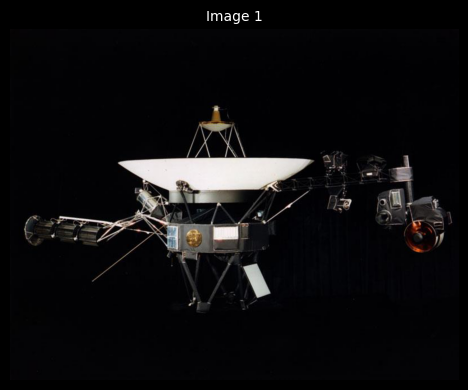

  Caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 to send it on to Ura

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Q2] 2
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was this photograph considered a major engineering milestone even though the spacecraft was still relatively close to Earth by solar system standards?

⏱ Retrieval Timings:
  Text:  0.0325 sec
  Image: 0.0117 sec
  Total: 0.132 sec

📊 Cosine Similarity:
  Combined: 0.5857

📄 TEXT CONTEXT:
[1] First photograph of the Earth-Moon system in a single frame (left), taken by Voyager 1 on S

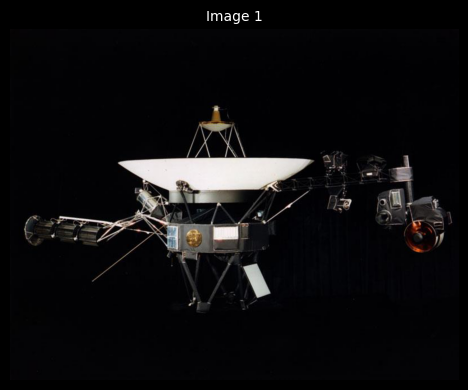

  Caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 to send it on to Ura

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Q3] 3
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: What specific visual features in this montage support the claims of active volcanoes on Io and a possible subsurface ocean on Europa?

⏱ Retrieval Timings:
  Text:  0.0379 sec
  Image: 0.0128 sec
  Total: 0.1212 sec

📊 Cosine Similarity:
  Combined: 0.5307

📄 TEXT CONTEXT:
[1] This image series, starting in the lower right corner, shows the 
darkening of Jupiter’s clouds as a result of 

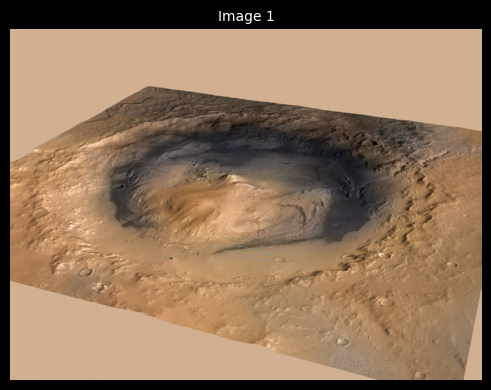

  Caption: favorable for microbial life and for preserving clues in the rocks about possible past life. More th

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Q4] 4
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why did the mission team deliberately wait until just before permanently shutting down the cameras to capture this image, and what deeper message does it convey?

⏱ Retrieval Timings:
  Text:  0.0287 sec
  Image: 0.0112 sec
  Total: 0.1243 sec

📊 Cosine Similarity:
  Combined: 0.4307

📄 TEXT CONTEXT:
[1] Montage of Uranus and several of its larger moons (left) and of Neptune and its lar

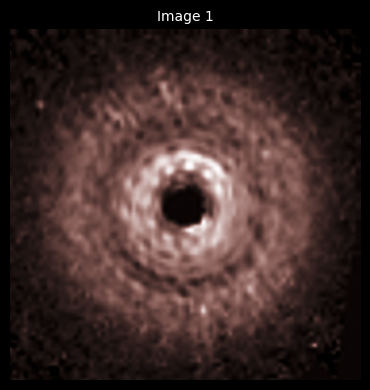

  Caption: Hubble Image
Illustration

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Q5] 5
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was 1970s analog technology deliberately chosen for a message that might be found tens of thousands of years in the future?

⏱ Retrieval Timings:
  Text:  0.0291 sec
  Image: 0.0109 sec
  Total: 0.1228 sec

📊 Cosine Similarity:
  Combined: 0.438

📄 TEXT CONTEXT:
[1] With their planetary encounters over, the spacecraft began the Voyager Interstellar Mission (VIM) in 
1989, in which they are going where no man-made spacecraft has gone before, exploring uncha

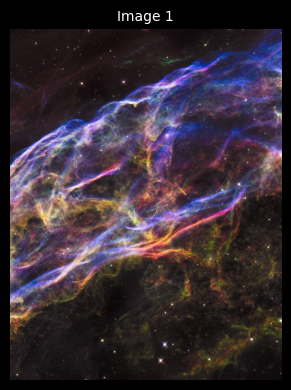

  Caption: National Aeronautics and Space Administration

----------------------------------------------------------------------------------------------------------------------------------------------------------------



In [50]:
display_formatted_results(retrieval_output, formatter)